This notebook models Japan's day-ahead electricity market (JEPX). See README.md in this repo for a summary of the methodology and results. The dataset (`JEPX_DayAheadMarket.csv`) is not included — see README.md for how to obtain it.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/jepx-dayaheadmarket/JEPX_DayAheadMarket.csv


In [2]:
data_jpex = pd.read_csv("/kaggle/input/jepx-dayaheadmarket/JEPX_DayAheadMarket.csv")
data_jpex.tail()

,date_time,Sell bid amount,Buy bid amount,Total contract amount,System price,Hokkaido area price,Tohoku area price,Tokyo area price,Chubu area price,Hokuriku area price,Kansai area price,Chugoku area price,Shikoku area price,Kyushu area price,Sell block bid total amount,Total sell block execution amount,Buy block bid total amount,Total buy block total amount
365995,2026/02/15 21:30:00,29730850,20187550,15921550,9.78,10.41,10.41,10.41,10.26,10.26,8.86,8.86,7.35,8.86,11635600.0,1071300.0,1836650.0,1386650.0
365996,2026/02/15 22:00:00,29615600,19535600,15366150,10.23,10.36,10.36,10.57,10.57,10.26,8.67,8.67,7.55,8.67,12263950.0,1122700.0,1484550.0,1034550.0
365997,2026/02/15 22:30:00,30264400,18871650,15224550,9.33,9.82,9.82,10.32,10.32,8.27,8.27,8.27,7.53,8.27,12642100.0,1180150.0,1141200.0,841200.0
365998,2026/02/15 23:00:00,29609750,18259850,15179850,8.45,9.00,9.00,9.00,8.50,8.08,8.08,8.08,7.61,8.08,12074150.0,1122400.0,992600.0,792600.0
365999,2026/02/15 23:30:00,28121250,17210850,14727700,7.88,9.78,9.78,9.78,7.40,7.40,7.40,7.40,7.40,7.40,11156150.0,1051250.0,621700.0,521700.0


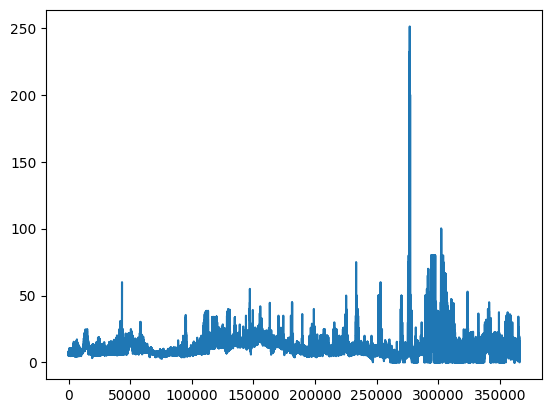

In [3]:
import matplotlib.pyplot as plt

plt.plot(data_jpex["System price"])
plt.show()

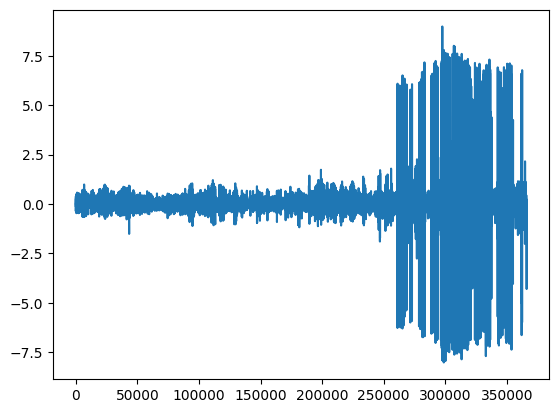

In [4]:
#SHIFT 48 TO AVOID DATA LEAKAGE EXPLAINATION FURTHER IN THE NOTEBOOK

data_jpex["return"] = np.log(data_jpex["System price"]/data_jpex["System price"].shift(48))
plt.plot(data_jpex["return"])
plt.show()

#log return are not good to use for this market (because its common to have a price that goes 0.01 to 15yen/KwH <=> HUGE SPIKE)
#as we can see, log returns of +/-600%...
#test 1) log(price + 1), 2) .diff (net diff in Yen block to block) and price only
data_jpex["log_price"] = np.log(data_jpex["System price"] + 1)
data_jpex["difference"] = data_jpex["System price"] - data_jpex["System price"].shift(48)

In [5]:
#stationnarity test on transformation
from statsmodels.tsa.stattools import adfuller

def run_adf_test(series):
    result = adfuller(series.dropna())
    print(f'ADF Statistics : {result[0]}')
    print(f'p-value : {result[1]}')
    if result[1] <= 0.05:
        print("Verdict : Stationnary (Reject of H0)")
    else:
        print("Verdict : Non-stationnary (Non-reject o H0)")

# Test
run_adf_test(data_jpex["return"])
run_adf_test(data_jpex["log_price"])
run_adf_test(data_jpex["difference"])
run_adf_test(data_jpex["System price"])

#even the raw price is stationnary, very nice, will be easier than stock or other assets

ADF Statistics : -106.82101093471091
p-value : 0.0
Verdict : Stationnary (Reject of H0)
ADF Statistics : -15.341461930619447
p-value : 3.8261060263173933e-28
Verdict : Stationnary (Reject of H0)
ADF Statistics : -83.67958983769168
p-value : 0.0
Verdict : Stationnary (Reject of H0)
ADF Statistics : -15.355385397151691
p-value : 3.672707332458427e-28
Verdict : Stationnary (Reject of H0)


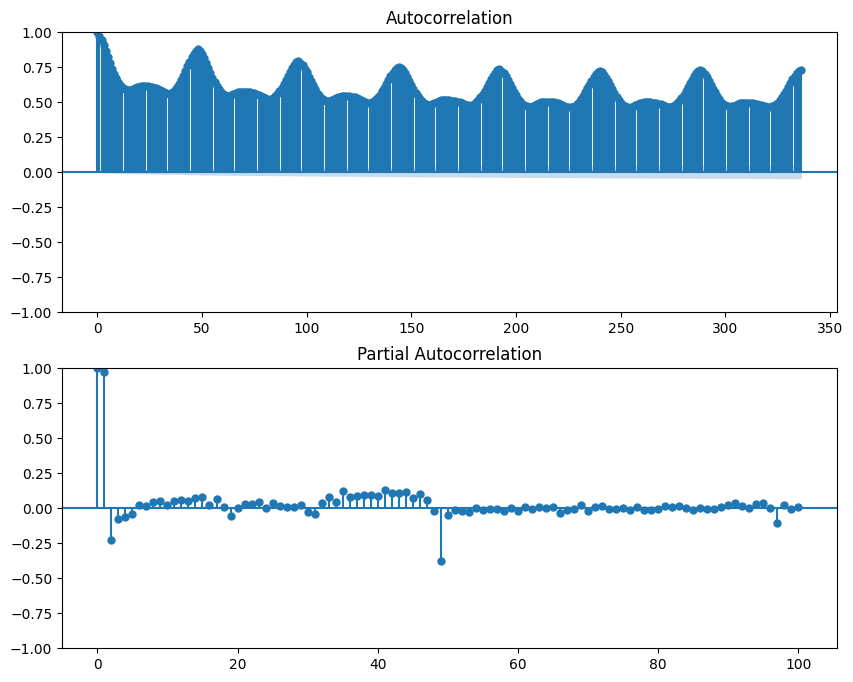

In [6]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# On regarde les lags sur 2 jours (96 blocs)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
plot_acf(data_jpex["System price"], lags=336, ax=ax1) #336 is a week
plot_pacf(data_jpex["System price"], lags=100, ax=ax2)
plt.show()

# Stationarity, ACF and PACF results

Raw price and all transformations are stationnary by Dickey-Fuller test => $\mu$ and $\sigma$ does not depend on $t$ => way easier for a model to learn this kind of series

- ACF analysis : peak at 48 => makes sense, 48 is exaclty one day, we actualy have a peak 48, 96... multiple of 48\
  It tells us => a pattern repeat each 48 blocks (each day), 96, ...
- PACF analysis : peak at 1,2,48... => means price 30m, 1h and 24h ago gives information, there is a direct correlation between the $S_t$, $S_{t-1}$, $S_{t-2}$ and $S_{t-48}$  => features to add .shift(1)...

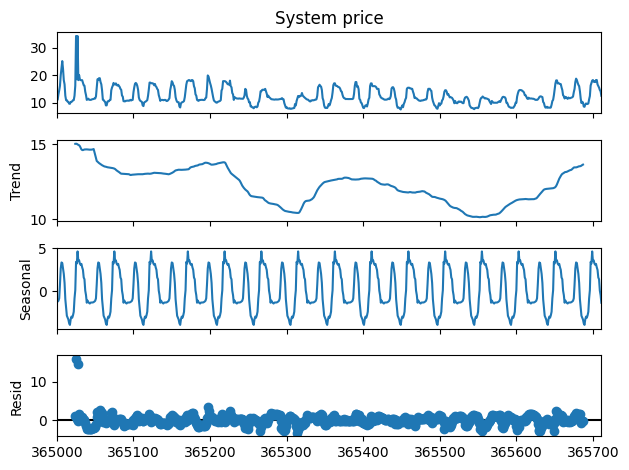

In [7]:
#seasonality 
#this market have a strong seasonality depending on the sun activity 
#(market price high when no sun activity, price low when peak of sun activity since way more electricity to sell)
#we choose a period = 48 because here a day is composed of 48 block of 30min and ACF analysis argument
from statsmodels.tsa.seasonal import seasonal_decompose
decoomp = seasonal_decompose(data_jpex["System price"].iloc[365000:], model='additive', period=48)

decoomp.plot()
plt.show()

In [8]:
from statsmodels.stats.diagnostic import acorr_ljungbox


residus = decoomp.resid.dropna()
lb_test = acorr_ljungbox(residus, lags=[10], return_df=True)
print(lb_test)

       lb_stat      lb_pvalue
10  548.820974  1.602451e-111


# Seasonality and residual analysis

- Huge seasonality within a range of +-5 yen/KwH => a difference of 10 yens in the price can be explained just by the timestamp
- Lljung-Box test p-value < 0.05 => residuals by decomposition are not white noise => we still have some information to capture and the actual price doesnt only depends on time => satellite (any) features are useful !

In [5]:
#create useful features from raw price

#data_jpex["shift1"] = data_jpex["System price"].shift(1) THOSE ONE ARE NOT ALLOWED TO AVOID DATA LEAKAGE
#data_jpex["shift2"] = data_jpex["System price"].shift(2)
data_jpex["shift48"] = data_jpex["System price"].shift(48)

# Data leakage issue

Make sure to shift EACH FEATURES related to the price by one day (48 blocs), because you don't know the Tokyo area price at time $t+1$ when you try to predict for it.\
So the data you have when you try to predict time $t+1$ is data at time $t$ => shift all features by 48.
And your target is the actual System price at time t.

In [6]:
#ALL THOSE FEATURES HAS TO BE SHIFTED BY ONE DAY
#print(data_jpex.columns)
col = ['Sell bid amount', 'Buy bid amount',
       'Total contract amount', 'Hokkaido area price',
       'Tohoku area price', 'Tokyo area price', 'Chubu area price',
       'Hokuriku area price', 'Kansai area price', 'Chugoku area price',
       'Shikoku area price', 'Kyushu area price',
       'Sell block bid total amount', 'Total sell block execution amount',
       'Buy block bid total amount', 'Total buy block total amount',
       'log_price', 'difference',"return"]

for i in col:
    data_jpex[i] = data_jpex[i].shift(48)

In [7]:
#ML
import torch
from torch import nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Deep learning

Let's try some DL, the horizon selected will be 30min with 1 day of context (we use 48 previous blocks to predict the next one).

- Test simple NN
- Test on LSTM
- Test on XGBOOST

Then we are going to prove that we can do better with more features such as weather. (to prove that satellite data can help improve those models). We can also use dim reduction method (auto encoder).

In [8]:
#setting date time as index and features related to time 
data_jpex['date_time'] = pd.to_datetime(data_jpex['date_time'])

data_jpex['hour'] = data_jpex['date_time'].dt.hour + data_jpex['date_time'].dt.minute / 60
data_jpex['hour_sin'] = np.sin(2 * np.pi * data_jpex['hour'] / 24)
data_jpex['hour_cos'] = np.cos(2 * np.pi * data_jpex['hour'] / 24)
data_jpex['is_weekend'] = data_jpex['date_time'].dt.dayofweek.isin([5, 6]).astype(int)

data_jpex.set_index('date_time', inplace=True)
data_jpex.sort_index(inplace=True)
data_jpex = data_jpex.asfreq('30min')



In [9]:
#cleaning data
#drop NaN row cause of shift
data_jpex = data_jpex.dropna()

In [15]:
#splitting and scaling data
window_size = 48 #we need this to include the first window necessary in the test to be able to predict
train_df = data_jpex.iloc[:round(len(data_jpex)*0.8)]
test_df = data_jpex.iloc[round(len(data_jpex)*0.8)-window_size:]

#we need a scaler for target and feature, otherwise it wont be possible to inverse our predictions (we only pred the price not all features)
target_scaler = StandardScaler()
feature_scaler = StandardScaler()

target_col = 'System price' 

target_scaler.fit(train_df[[target_col]])
train_target_scaled = target_scaler.transform(train_df[[target_col]])
test_target_scaled = target_scaler.transform(test_df[[target_col]])

features_df_train = train_df.drop(columns=[target_col])
features_df_test = test_df.drop(columns=[target_col])

feature_scaler.fit(features_df_train)
train_features_scaled = feature_scaler.transform(features_df_train)
test_features_scaled = feature_scaler.transform(features_df_test)

#we recombine dataset
train_scaled = np.hstack([train_target_scaled, train_features_scaled])
test_scaled = np.hstack([test_target_scaled, test_features_scaled])

train_scaled

array([[-3.43007604e-01, -2.34768182e+00, -2.51102697e+00, ...,
        -1.56487122e-04,  1.41416804e+00, -6.33352905e-01],
       [-4.49927257e-01, -2.14103501e+00, -2.50270404e+00, ...,
         1.84432908e-01,  1.40206908e+00, -6.33352905e-01],
       [-4.66310107e-01, -1.95901408e+00, -2.51579532e+00, ...,
         3.65863928e-01,  1.36597922e+00, -6.33352905e-01],
       ...,
       [-3.13690925e-01,  1.06060542e+00, -8.06507980e-01, ...,
         1.22457169e+00, -7.07181249e-01, -6.33352905e-01],
       [-2.74027182e-01,  1.19975787e+00, -7.19013164e-01, ...,
         1.12179928e+00, -8.60995236e-01, -6.33352905e-01],
       [-2.55057566e-01,  1.30461229e+00, -6.93706251e-01, ...,
         9.99829885e-01, -1.00007846e+00, -6.33352905e-01]])

In [10]:
#transform our 2D array to 3D since we need context window

def create_sequences(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i : i + window_size,1:])
        y.append(data[i + window_size, 0]) # predict first block
    return np.array(X), np.array(y)


In [17]:
X_train, y_train = create_sequences(train_scaled, window_size)
X_test, y_test = create_sequences(test_scaled, window_size)
print(f"X_train shape : {X_train.shape}")
# 120835 (days) matrix of (48x24) (context size as row and 24 columns for 24 features)
print(f"y_train shape : {y_train.shape}")
# array of 120835 

X_train shape : (120835, 48, 24)
y_train shape : (120835,)


In [18]:
#batching and tensor format
from torch.utils.data import DataLoader, TensorDataset
device = "cuda" if torch.cuda.is_available() else "cpu"

X_train, y_train,X_test, y_test = torch.from_numpy(X_train).type(torch.float).to(device),torch.from_numpy(y_train).type(torch.float).to(device),torch.from_numpy(X_test).type(torch.float).to(device),torch.from_numpy(y_test).type(torch.float).to(device)
y_train = y_train.unsqueeze(1)
y_test = y_test.unsqueeze(1)

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

batch_size = 1024 
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True) 
#very important to shuffle so the model each batch have a view of different temporality 
#(if you dont shuffle it will see for exemple only january oone batch then penalize a lot, but next batch its february etc)*
#=> gradient is optimizing for a certain temporality each batch
#shuffling gives multiple temporality each batch and the gradient is optimizing smoothly
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Test using NN

In [33]:
class NeuralNetworkJPEX(nn.Module):
    def __init__(self,dim2,dim3,hidden_unit):
        super().__init__()

        self.layer_stack = nn.Sequential(
            nn.Flatten(),# here we flatten to get a single vector of size dim2*dim3
            nn.Linear(in_features = dim2*dim3,out_features = hidden_unit),
            nn.ReLU(),
            nn.Linear(in_features = hidden_unit,out_features = hidden_unit),
            nn.ReLU(),
            nn.Linear(in_features = hidden_unit,out_features = hidden_unit),
            nn.ReLU(),
            nn.Linear(in_features = hidden_unit,out_features = hidden_unit),
            nn.ReLU(),
            nn.Linear(in_features = hidden_unit,out_features = 1)
        )

    def forward(self,x : torch.Tensor) -> torch.Tensor :
        return self.layer_stack(x)



NN_model = NeuralNetworkJPEX(X_train.shape[1],X_train.shape[2],2**11).to(device)

loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(NN_model.parameters(),lr = 0.001)

In [53]:
#training NN

torch.manual_seed(91)
epoch = 100


learning_cost_train = []
learning_cost_test = []

for i in range(epoch):
    NN_model.train()
    total_train_cost = 0
    
    for batch_X,batch_y in train_loader:
        optimizer.zero_grad()
    
        pred = NN_model(batch_X)
    
        cost = loss_fn(pred,batch_y)
    
        cost.backward()
    
        optimizer.step()
        total_train_cost += cost

    avg_train_cost = total_train_cost / len(train_loader)
    
    if i%10 == 0:
        NN_model.eval()
        total_test_cost = 0
        with torch.inference_mode():
            for batch_X,batch_y in test_loader:
                pred_test = NN_model(batch_X)
                cost_test = loss_fn(pred_test,batch_y)
                total_test_cost += cost_test

            avg_test_cost = total_test_cost / len(test_loader)
            learning_cost_train.append(avg_train_cost)
            learning_cost_test.append(avg_test_cost)
        print(f"Epoch {i} : Avg Train MAE cost = {avg_train_cost} | Avg Test MAE cost = {avg_test_cost}")



Epoch 0 : Avg Train MAE cost = 0.18966539204120636 | Avg Test MAE cost = 0.13169538974761963
Epoch 10 : Avg Train MAE cost = 0.18879583477973938 | Avg Test MAE cost = 0.1316390037536621
Epoch 20 : Avg Train MAE cost = 0.18782258033752441 | Avg Test MAE cost = 0.13155493140220642
Epoch 30 : Avg Train MAE cost = 0.18936902284622192 | Avg Test MAE cost = 0.13145965337753296
Epoch 40 : Avg Train MAE cost = 0.18721653521060944 | Avg Test MAE cost = 0.13146112859249115
Epoch 50 : Avg Train MAE cost = 0.18586823344230652 | Avg Test MAE cost = 0.1312444806098938
Epoch 60 : Avg Train MAE cost = 0.18479548394680023 | Avg Test MAE cost = 0.1314445436000824
Epoch 70 : Avg Train MAE cost = 0.18404603004455566 | Avg Test MAE cost = 0.13143210113048553
Epoch 80 : Avg Train MAE cost = 0.18366916477680206 | Avg Test MAE cost = 0.1311488151550293
Epoch 90 : Avg Train MAE cost = 0.18320876359939575 | Avg Test MAE cost = 0.13123510777950287


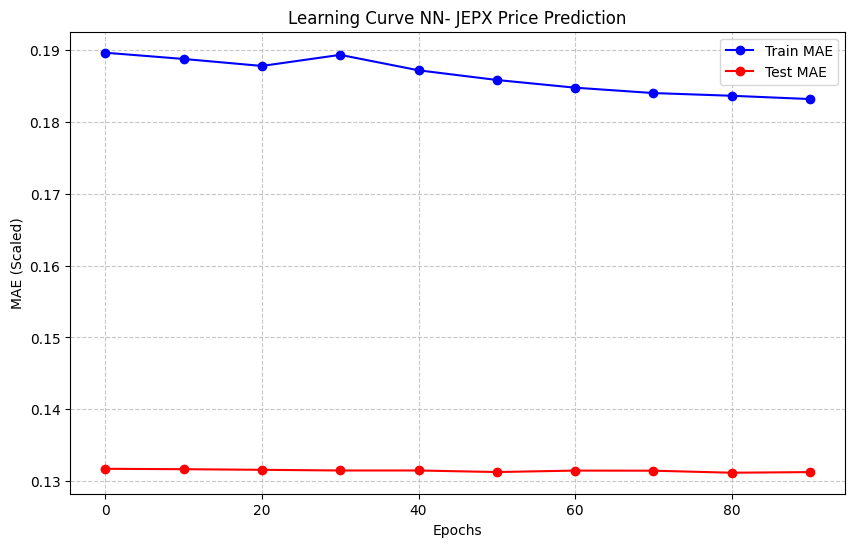

In [54]:
#learning curve
train_costs = [c.item() if torch.is_tensor(c) else c for c in learning_cost_train] #list of tensor, we have to convert to float
test_costs = [c.item() if torch.is_tensor(c) else c for c in learning_cost_test]

epochs_axis = range(0, epoch, 10)

plt.figure(figsize=(10, 6))
plt.plot(epochs_axis, train_costs, label='Train MAE', color='blue', marker='o')
plt.plot(epochs_axis, test_costs, label='Test MAE', color='red', marker='o')

plt.title('Learning Curve NN- JEPX Price Prediction')
plt.xlabel('Epochs')
plt.ylabel('MAE (Scaled)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

The fact that the test MAE sometimes spikes again and train MAE constantly decreasing is often a sign that there is no data leakage...

In [55]:
#Prediction test

NN_model.eval()
predictions = []
actuals = []

with torch.inference_mode():
    for batch_X, batch_y in test_loader:
        preds = NN_model(batch_X)
        predictions.append(preds)
        actuals.append(batch_y)

# Transform preds for each batch in one pred vector
predictions_np = torch.cat(predictions).cpu().numpy()
actuals_np = torch.cat(actuals).cpu().numpy()

# Inversion
predictions_final = target_scaler.inverse_transform(predictions_np)
actuals_final = target_scaler.inverse_transform(actuals_np)

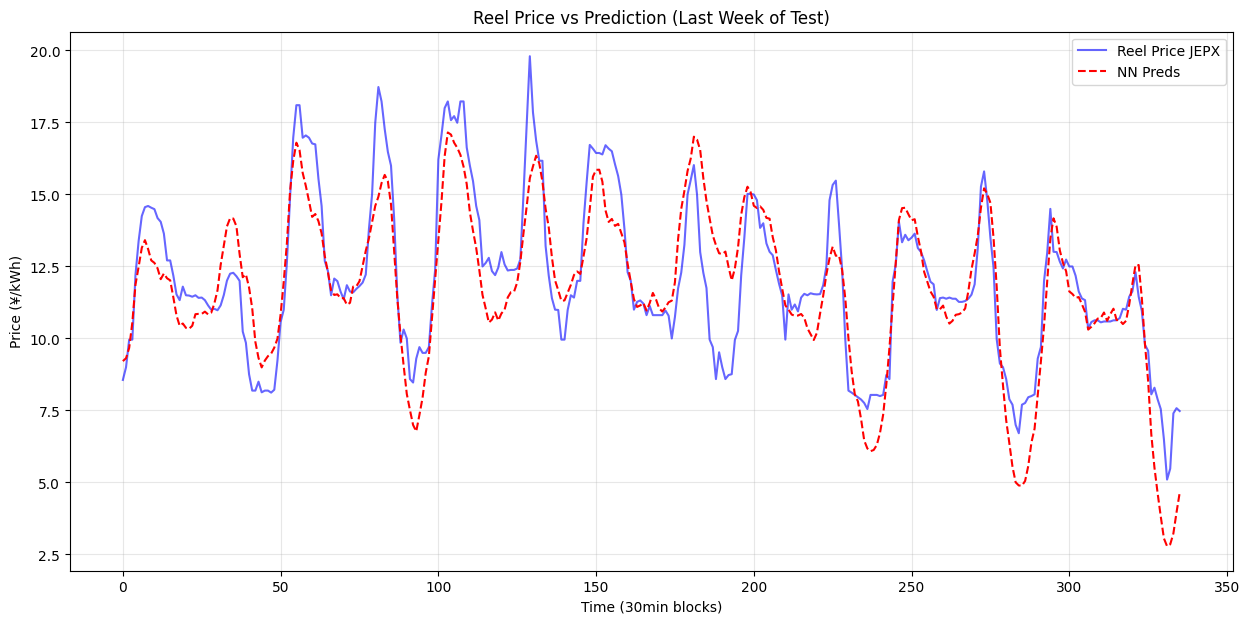

In [56]:
plt.figure(figsize=(15, 7))

# take last week
points_to_plot = 336 

plt.plot(actuals_final[-points_to_plot:], label='Reel Price JEPX', color='blue', alpha=0.6)
plt.plot(predictions_final[-points_to_plot:], label='NN Preds', color='red', linestyle='--')

plt.title('Reel Price vs Prediction (Last Week of Test)')
plt.xlabel('Time (30min blocks)')
plt.ylabel('Price (¥/kWh)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

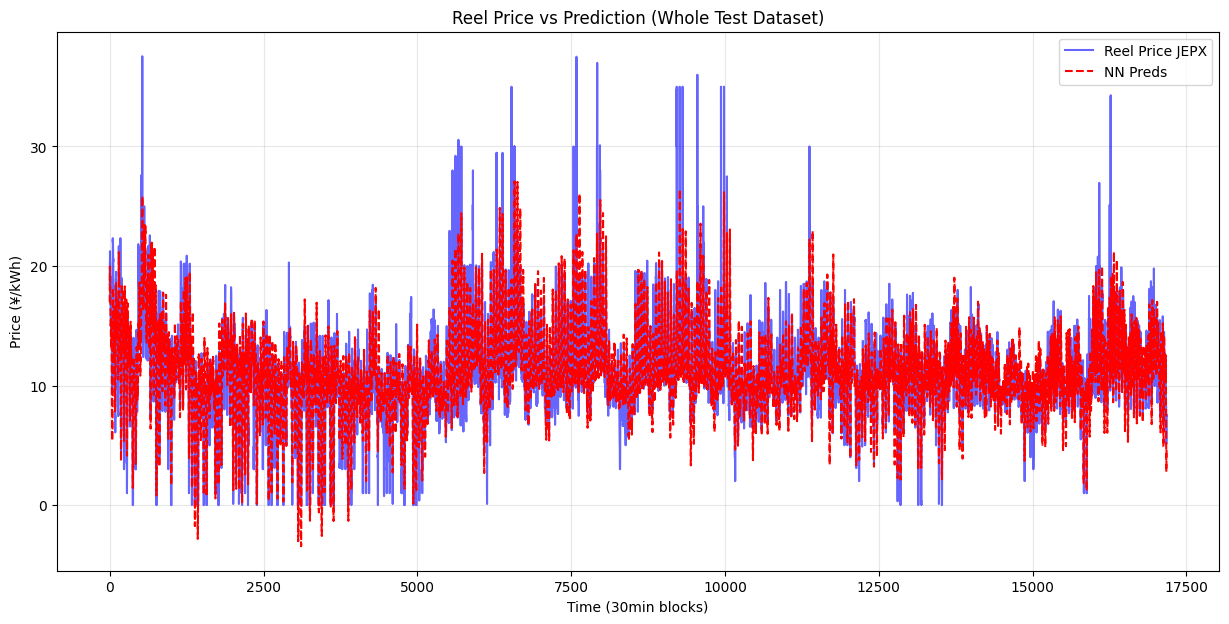

In [57]:
plt.figure(figsize=(15, 7))
plt.plot(actuals_final, label='Reel Price JEPX', color='blue', alpha=0.6)
plt.plot(predictions_final, label='NN Preds', color='red', linestyle='--')

plt.title('Reel Price vs Prediction (Whole Test Dataset)')
plt.xlabel('Time (30min blocks)')
plt.ylabel('Price (¥/kWh)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Test using LSTM

In [58]:
class LSTM_JEPX(nn.Module):
    def __init__(self,input_size,hidden_size,num_layers,dropout=0.2):
        super().__init__()
        
        #LSTM adapt automatically how much row you give him
        self.lstm = nn.LSTM(
            input_size = input_size, # dimension number features
            hidden_size = hidden_size,
            num_layers = num_layers, 
            batch_first = True,
            dropout = dropout
        )

        self.fc = nn.Linear(hidden_size,1)

    def forward(self,x:torch.Tensor) -> torch.Tensor:
        #x shape = (Batch_size,48,23)
        
        out, (hn,cn) = self.lstm(x)
        
        out = self.fc(hn[-1])

        return out

LSTM_model = LSTM_JEPX(X_train.shape[2],512,3).to(device)
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(LSTM_model.parameters(),lr = 0.002)

In [59]:
#training LSTM
torch.manual_seed(91)
epochs = 1000

learning_cost_train = []
learning_cost_test = []

for i in range(epochs):
    LSTM_model.train()
    total_train_cost = 0
    
    for batch_X, batch_y in train_loader:
        
        optimizer.zero_grad()
        
        
        pred = LSTM_model(batch_X)
        
        
        cost = loss_fn(pred, batch_y)
        
        
        cost.backward()
        
        # 
        torch.nn.utils.clip_grad_norm_(LSTM_model.parameters(), max_norm=1.0)
        
        
        optimizer.step()
        
        total_train_cost += cost.item()

    avg_train_cost = total_train_cost / len(train_loader)
    
    
    LSTM_model.eval()
    total_test_cost = 0
    with torch.inference_mode():
        for batch_X, batch_y in test_loader:
            pred_test = LSTM_model(batch_X)
            cost_test = loss_fn(pred_test, batch_y)
            total_test_cost += cost_test.item()

    avg_test_cost = total_test_cost / len(test_loader)
    
    
    learning_cost_train.append(avg_train_cost)
    learning_cost_test.append(avg_test_cost)

    # Affichage du progrès
    if i % 5 == 0:
        print(f"Epoch {i} : Avg Train MAE = {avg_train_cost:.6f} | Avg Test MAE = {avg_test_cost:.6f}")

OutOfMemoryError: CUDA out of memory. Tried to allocate 12.80 GiB. GPU 0 has a total capacity of 15.89 GiB of which 7.26 GiB is free. Process 3080 has 8.62 GiB memory in use. Of the allocated memory 8.24 GiB is allocated by PyTorch, and 90.71 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

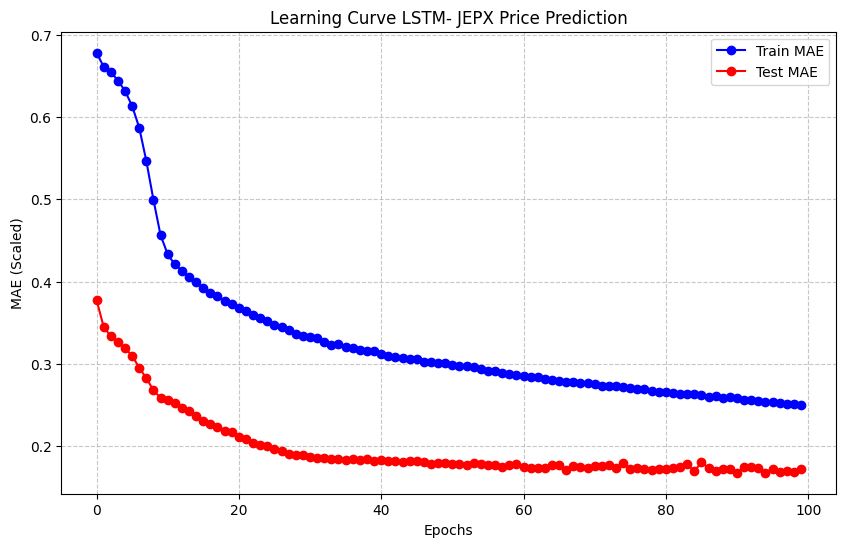

In [32]:
#learning curve

epochs_axis = range(0, epochs, 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs_axis, learning_cost_train, label='Train MAE', color='blue', marker='o')
plt.plot(epochs_axis, learning_cost_test, label='Test MAE', color='red', marker='o')

plt.title('Learning Curve LSTM- JEPX Price Prediction')
plt.xlabel('Epochs')
plt.ylabel('MAE (Scaled)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [33]:
#Prediction test

LSTM_model.eval()
predictions = []
actuals = []

with torch.inference_mode():
    for batch_X, batch_y in test_loader:
        preds = LSTM_model(batch_X)
        predictions.append(preds)
        actuals.append(batch_y)

# Transform preds for each batch in one pred vector
predictions_np = torch.cat(predictions).cpu().numpy()
actuals_np = torch.cat(actuals).cpu().numpy()

# Inversion
predictions_final = target_scaler.inverse_transform(predictions_np)
actuals_final = target_scaler.inverse_transform(actuals_np)

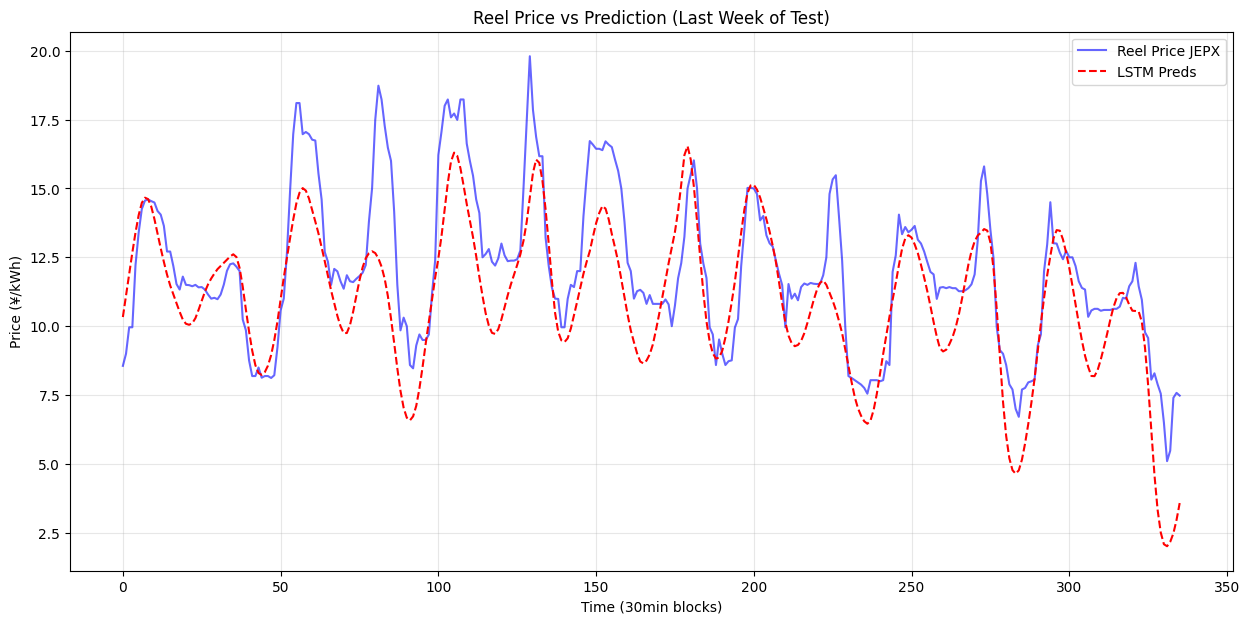

In [34]:
plt.figure(figsize=(15, 7))

# take last week
points_to_plot = 336 

plt.plot(actuals_final[-points_to_plot:], label='Reel Price JEPX', color='blue', alpha=0.6)
plt.plot(predictions_final[-points_to_plot:], label='LSTM Preds', color='red', linestyle='--')

plt.title('Reel Price vs Prediction (Last Week of Test)')
plt.xlabel('Time (30min blocks)')
plt.ylabel('Price (¥/kWh)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

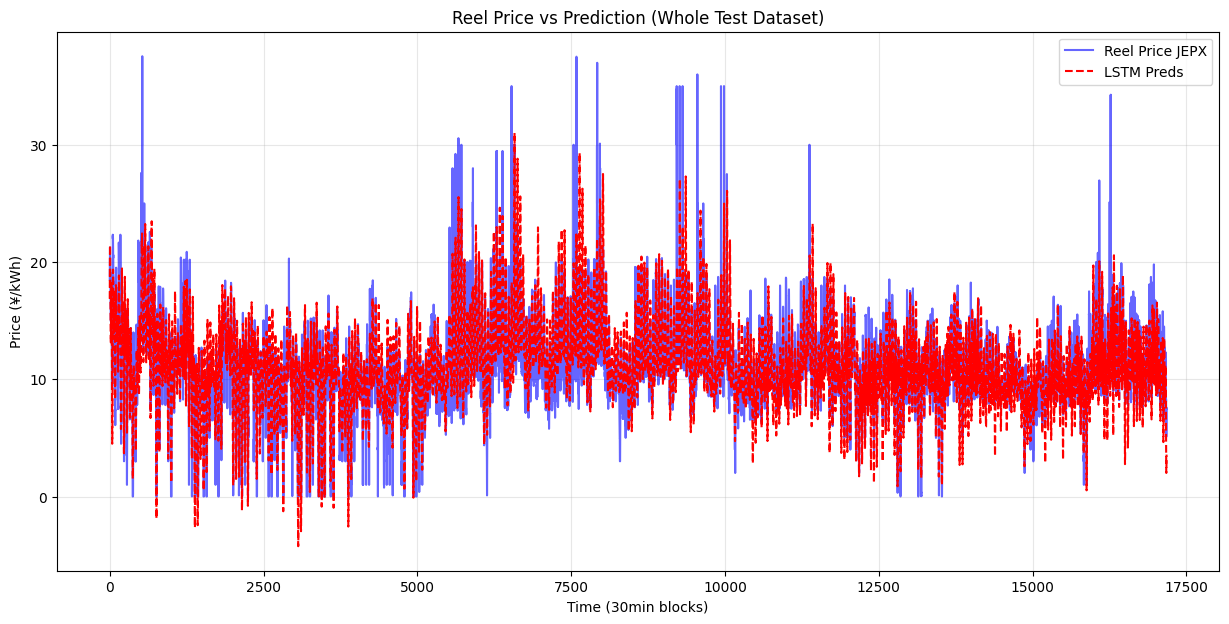

In [35]:
plt.figure(figsize=(15, 7))
plt.plot(actuals_final, label='Reel Price JEPX', color='blue', alpha=0.6)
plt.plot(predictions_final, label='LSTM Preds', color='red', linestyle='--')

plt.title('Reel Price vs Prediction (Whole Test Dataset)')
plt.xlabel('Time (30min blocks)')
plt.ylabel('Price (¥/kWh)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Testing statistcal model

# Adding weather data

Here the goal is to use forecast of Japan weather to prove that this kind of informatioon helps to model electric market i.e using satelitte data will be very useful.

- Why forecast ? since you want to predict at $t+1$ the cost of electricity, it makes totally sense to have forecast of $t+1$, its not data leakage since its forecast and not true weather.
- True weather at time $t$ can probably help too, be aware of data leakage here.

In [11]:
!pip install openmeteo-requests
!pip install requests-cache retry-requests

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.4/183.4 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 685.7/685.7 kB 33.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.8/138.8 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.1/394.1 kB 25.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 57.4 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.6/69.6 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.7/70.7 kB 5.1 MB/s eta 0:00:00


# Downloading historical weather forecast of Japan

We are interested into weather forecast of those area :

'Hokkaido area price',
       'Tohoku area price', 'Tokyo area price', 'Chubu area price',
       'Hokuriku area price', 'Kansai area price', 'Chugoku area price',
       'Shikoku area price', 'Kyushu area price''Hokkaido area price',
       'Tohoku area price', 'Tokyo area price', 'Chubu area price',
       'Hokuriku area price', 'Kansai area price', 'Chugoku area price',
       'Shikoku area price', 'Kyushu area price'

**Note on Data Leakage and Weather Forecasts**

**The Context**: The JEPX (Japan Electric Power Exchange) is a Day-Ahead market. This means prices for "Day J" are finalized during auctions that close at 10:00 AM on Day J-1. To be 100% realistic, a predictive model should only use weather forecasts that were available before that specific cutoff time.

**The Technical Constraint**: The Open-Meteo Historical Forecast API provides the "Morning Run" forecast, which is generated at 00:00 AM on Day J. Technically, using this data creates a minor Look-Ahead Bias (a form of data leakage), because this specific forecast update would not have been available to traders 14 hours earlier during the J-1 auction.

**The Justification**: We have chosen to proceed with the Day J (00:00 AM) forecast without shifting the data for the following reasons:

- Physical Correlation: The LSTM model needs to learn the direct relationship between weather conditions (e.g., solar radiation at 12:00 PM) and prices at that same moment. Shifting the data would break this physical link and degrade the model's learning capability.

- Real-World Availability: In a production environment, high-resolution historical forecast archives (showing exactly what was predicted at 10:00 AM J-1 for the next day) are usually premium/paid services.

- Proxy Accuracy: In meteorology, the difference between a 24-hour forecast and a 38-hour forecast is statistically marginal. The 00:00 AM forecast serves as an excellent proxy for the information traders had, capturing the essential atmospheric trends required for price prediction.

In [13]:
import openmeteo_requests
import requests_cache
from retry_requests import retry

# 1. Set up API with cache
cache_session = requests_cache.CachedSession('.cache', expire_after=3600)
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
openmeteo = openmeteo_requests.Client(session=retry_session)

url = "https://historical-forecast-api.open-meteo.com/v1/forecast"

# 2. Reuse the JEPX location table
jepx_locations = {
    'Hokkaido area price': {'city': 'Sapporo', 'lat': 43.0618, 'lon': 141.3545},
    'Tohoku area price':   {'city': 'Sendai',  'lat': 38.2682, 'lon': 140.8694},
    'Tokyo area price':    {'city': 'Tokyo',   'lat': 35.6895, 'lon': 139.6917},
    'Chubu area price':    {'city': 'Nagoya',  'lat': 35.1815, 'lon': 136.9066},
    'Hokuriku area price': {'city': 'Kanazawa','lat': 36.5613, 'lon': 136.6562},
    'Kansai area price':   {'city': 'Osaka',   'lat': 34.6937, 'lon': 135.5023},
    'Chugoku area price':  {'city': 'Hiroshima','lat': 34.3853, 'lon': 132.4553},
    'Shikoku area price':  {'city': 'Takamatsu','lat': 34.3428, 'lon': 134.0466},
    'Kyushu area price':   {'city': 'Fukuoka',  'lat': 33.5904, 'lon': 130.4017} 
}

# Explicit variable list (avoids index mistakes)
hourly_vars = ["cloud_cover", "wind_speed_10m", "temperature_2m", "direct_radiation", "relative_humidity_2m"]

all_forecast_df = []

for key, value in jepx_locations.items():
    print(f"Downloading forecast for {value['city']}...")
    
    params = {
        "latitude": value['lat'],
        "longitude": value['lon'],
        "start_date": "2016-01-01",
        "end_date": "2026-02-16",
        "hourly": hourly_vars,
        "timezone": "Asia/Tokyo" 
    }
    
    responses = openmeteo.weather_api(url, params=params)
    response = responses[0]
    hourly = response.Hourly()
    
    # 3. Extraction dynamique des variables (évite les erreurs d'index)
    data_dict = {}
    for i, var_name in enumerate(hourly_vars):
        data_dict[var_name] = hourly.Variables(i).ValuesAsNumpy()
    
    # 4. Création du DataFrame
    time_data = pd.date_range(
        start=pd.to_datetime(hourly.Time(), unit="s", utc=False),
        end=pd.to_datetime(hourly.TimeEnd(), unit="s", utc=False),
        freq=pd.Timedelta(seconds=hourly.Interval()),
        inclusive="left"
    )
    
    df = pd.DataFrame(data=data_dict, index=time_data)
    prefix = value['city'].lower()
    df = df.add_prefix(f'{prefix}_')
    # 5. Resample to 30-minute blocks pour matcher le JEPX  
    all_forecast_df.append(df.resample('30min').interpolate(method='linear')) 
    print(f"Done for {value['city']}. Shape: {df.shape}")

# Exemple de fusion finale (pour la zone Tokyo par exemple)
# data_final = data_jpex.join(jepx_locations['Tokyo area price']['df'])
df_final_forecast_weather = pd.concat(all_forecast_df, axis=1)

Téléchargement pour Sapporo...
Done for Sapporo. Shape: (88800, 5)
Téléchargement pour Sendai...
Done for Sendai. Shape: (88800, 5)
Téléchargement pour Tokyo...
Done for Tokyo. Shape: (88800, 5)
Téléchargement pour Nagoya...
Done for Nagoya. Shape: (88800, 5)
Téléchargement pour Kanazawa...
Done for Kanazawa. Shape: (88800, 5)
Téléchargement pour Osaka...
Done for Osaka. Shape: (88800, 5)
Téléchargement pour Hiroshima...
Done for Hiroshima. Shape: (88800, 5)
Téléchargement pour Takamatsu...
Done for Takamatsu. Shape: (88800, 5)
Téléchargement pour Fukuoka...
Done for Fukuoka. Shape: (88800, 5)


## True Weather Data but shifted

In [16]:
# URL for real historical weather data
url_real = "https://archive-api.open-meteo.com/v1/archive"

# Relevant real-weather variables
real_vars = ["temperature_2m", "shortwave_radiation", "relative_humidity_2m", "cloud_cover"]

# Reuse the jepx_locations table
all_real_weather = []

for key, value in jepx_locations.items():
    print(f"Downloading real weather for {value['city']}...")
    
    params = {
        "latitude": value['lat'],
        "longitude": value['lon'],
        "start_date": "2016-01-01",
        "end_date": "2026-02-14",
        "hourly": real_vars,
        "timezone": "Asia/Tokyo"
    }
    
    responses = openmeteo.weather_api(url_real, params=params)
    response = responses[0]
    hourly = response.Hourly()
    
    # Extract variables
    data_dict = {}
    for i, var_name in enumerate(real_vars):
        data_dict[var_name] = hourly.Variables(i).ValuesAsNumpy()
        
    # Build the DataFrame
    time_data = pd.date_range(
        start=pd.to_datetime(hourly.Time(), unit="s", utc=False),
        end=pd.to_datetime(hourly.TimeEnd(), unit="s", utc=False),
        freq=pd.Timedelta(seconds=hourly.Interval()),
        inclusive="left"
    )
    
    df_real = pd.DataFrame(data=data_dict, index=time_data)
    
    # Resample to 30-minute blocks
    df_real = df_real.resample('30min').interpolate(method='linear')
    
    # --- THE SHIFT (anti-leakage safeguard) ---
    # Shift by 24h: at time T the model only sees the weather from T-24h.
    df_real_lagged = df_real.shift(48)
    
    # Rename to distinguish from the forecast features
    prefix = value['city'].lower()
    df_real_lagged = df_real_lagged.add_prefix(f"{prefix}_real_lag24h_")
    
    all_real_weather.append(df_real_lagged)

# Merge all cities into one DataFrame
df_final_real_weather = pd.concat(all_real_weather, axis=1)

print("Columns created:", df_final_real_weather.columns[:5])

Téléchargement météo RÉELLE pour Sapporo...
Téléchargement météo RÉELLE pour Sendai...
Téléchargement météo RÉELLE pour Tokyo...
Téléchargement météo RÉELLE pour Nagoya...
Téléchargement météo RÉELLE pour Kanazawa...
Téléchargement météo RÉELLE pour Osaka...
Téléchargement météo RÉELLE pour Hiroshima...
Téléchargement météo RÉELLE pour Takamatsu...
Téléchargement météo RÉELLE pour Fukuoka...
Colonnes créées : Index(['sapporo_real_lag24h_temperature_2m',
       'sapporo_real_lag24h_shortwave_radiation',
       'sapporo_real_lag24h_relative_humidity_2m',
       'sapporo_real_lag24h_cloud_cover', 'sendai_real_lag24h_temperature_2m'],
      dtype='object')


In [17]:
df_final_real_weather

,sapporo_real_lag24h_temperature_2m,sapporo_real_lag24h_shortwave_radiation,sapporo_real_lag24h_relative_humidity_2m,sapporo_real_lag24h_cloud_cover,sendai_real_lag24h_temperature_2m,sendai_real_lag24h_shortwave_radiation,sendai_real_lag24h_relative_humidity_2m,sendai_real_lag24h_cloud_cover,tokyo_real_lag24h_temperature_2m,tokyo_real_lag24h_shortwave_radiation,...,hiroshima_real_lag24h_relative_humidity_2m,hiroshima_real_lag24h_cloud_cover,takamatsu_real_lag24h_temperature_2m,takamatsu_real_lag24h_shortwave_radiation,takamatsu_real_lag24h_relative_humidity_2m,takamatsu_real_lag24h_cloud_cover,fukuoka_real_lag24h_temperature_2m,fukuoka_real_lag24h_shortwave_radiation,fukuoka_real_lag24h_relative_humidity_2m,fukuoka_real_lag24h_cloud_cover
2015-12-31 15:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-12-31 15:30:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-12-31 16:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-12-31 16:30:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-12-31 17:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-14 12:00:00,-4.9325,0.0,94.474045,79.0,2.150,0.0,77.362869,38.0,6.100,0.0,...,88.587402,0.0,7.900,0.0,63.741463,0.0,4.050,0.0,97.228134,0.0
2026-02-14 12:30:00,-4.0325,0.0,89.782013,60.0,1.975,0.0,78.926773,66.5,5.900,0.0,...,88.406158,0.0,7.675,0.0,63.347565,0.0,3.450,0.0,98.614067,47.0
2026-02-14 13:00:00,-3.1325,0.0,85.089981,41.0,1.800,0.0,80.490669,95.0,5.700,0.0,...,88.224922,0.0,7.450,0.0,62.953663,0.0,2.850,0.0,100.000000,94.0
2026-02-14 13:30:00,-3.5325,0.0,83.293449,35.5,2.200,0.0,81.138123,95.5,5.175,0.0,...,88.031250,0.0,6.975,0.0,63.414925,0.0,2.475,0.0,99.822083,94.0


In [18]:
print(df_final_forecast_weather)

                     sapporo_cloud_cover  sapporo_wind_speed_10m  \
2015-12-31 15:00:00                  NaN                     NaN   
2015-12-31 15:30:00                  NaN                     NaN   
2015-12-31 16:00:00                  NaN                     NaN   
2015-12-31 16:30:00                  NaN                     NaN   
2015-12-31 17:00:00                  NaN                     NaN   
...                                  ...                     ...   
2026-02-16 12:00:00                 76.0                4.553679   
2026-02-16 12:30:00                 76.0                4.112487   
2026-02-16 13:00:00                 76.0                3.671294   
2026-02-16 13:30:00                 76.0                4.112487   
2026-02-16 14:00:00                 76.0                4.553679   

                     sapporo_temperature_2m  sapporo_direct_radiation  \
2015-12-31 15:00:00                     NaN                       NaN   
2015-12-31 15:30:00                  

In [19]:
full_df = pd.concat([df_final_forecast_weather,df_final_real_weather,data_jpex],axis=1)
full_df.dropna(inplace = True)
full_df

,sapporo_cloud_cover,sapporo_wind_speed_10m,sapporo_temperature_2m,sapporo_direct_radiation,sapporo_relative_humidity_2m,sendai_cloud_cover,sendai_wind_speed_10m,sendai_temperature_2m,sendai_direct_radiation,sendai_relative_humidity_2m,...,Buy block bid total amount,Total buy block total amount,return,log_price,difference,shift48,hour,hour_sin,hour_cos,is_weekend
2021-03-23 01:00:00,87.0,13.324863,5.0315,450.0,49.0,56.0,6.287130,7.676,137.918945,46.0,...,1497150.0,808200.0,-0.087675,1.795087,-0.46,5.02,1.0,2.588190e-01,0.965926,0.0
2021-03-23 01:30:00,89.0,14.303427,5.3315,487.0,45.0,51.0,6.940669,8.051,167.204590,46.5,...,1665850.0,880400.0,-0.114680,1.795087,-0.61,5.02,1.5,3.826834e-01,0.923880,0.0
2021-03-23 02:00:00,91.0,15.281989,5.6315,524.0,41.0,46.0,7.594207,8.426,196.490234,47.0,...,1724450.0,961250.0,-0.091056,1.814825,-0.49,5.14,2.0,5.000000e-01,0.866025,0.0
2021-03-23 02:30:00,95.5,15.668671,5.9315,532.0,40.0,41.0,8.033800,8.651,207.003983,47.5,...,2064100.0,1221650.0,-0.104224,1.837370,-0.58,5.28,2.5,6.087614e-01,0.793353,0.0
2021-03-23 03:00:00,100.0,16.055353,6.2315,540.0,39.0,36.0,8.473393,8.876,217.517731,48.0,...,2313200.0,1498500.0,-0.093982,1.868721,-0.54,5.48,3.0,7.071068e-01,0.707107,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-14 12:00:00,100.0,7.754637,-0.8885,0.0,86.0,67.0,5.860375,5.176,0.000000,76.0,...,3945000.0,3259100.0,-0.103072,2.079442,-0.76,7.00,12.0,1.224647e-16,-1.000000,1.0
2026-02-14 12:30:00,97.5,8.260605,-0.7135,0.0,85.5,67.0,5.185581,4.851,0.000000,77.5,...,3898250.0,3132350.0,-0.117949,2.042518,-0.84,6.71,12.5,-1.305262e-01,-0.991445,1.0
2026-02-14 13:00:00,95.0,8.766573,-0.5385,0.0,85.0,67.0,4.510787,4.526,0.000000,79.0,...,4048700.0,3299300.0,-0.043209,2.163323,-0.34,7.70,13.0,-2.588190e-01,-0.965926,1.0
2026-02-14 13:30:00,91.0,8.408209,-0.2635,0.0,84.5,72.5,4.362239,4.276,0.000000,81.5,...,3848800.0,3323900.0,-0.035447,2.170196,-0.28,7.76,13.5,-3.826834e-01,-0.923880,1.0


In [21]:
#splitting and scaling data
window_size = 48 #we need this to include the first window necessary in the test to be able to predict
train_df = full_df.iloc[:round(len(full_df)*0.8)]
test_df = full_df.iloc[round(len(full_df)*0.8)-window_size:]

#we need a scaler for target and feature, otherwise it wont be possible to inverse our predictions (we only pred the price not all features)
target_scaler = StandardScaler()
feature_scaler = StandardScaler()

target_col = 'System price' 

target_scaler.fit(train_df[[target_col]])
train_target_scaled = target_scaler.transform(train_df[[target_col]])
test_target_scaled = target_scaler.transform(test_df[[target_col]])

features_df_train = train_df.drop(columns=[target_col])
features_df_test = test_df.drop(columns=[target_col])

feature_scaler.fit(features_df_train)
train_features_scaled = feature_scaler.transform(features_df_train)
test_features_scaled = feature_scaler.transform(features_df_test)

#we recombine dataset
train_scaled = np.hstack([train_target_scaled, train_features_scaled])
test_scaled = np.hstack([test_target_scaled, test_features_scaled])

train_scaled

array([[-0.94091988,  0.58241205,  0.47253938, ...,  0.36580571,
         1.36618158, -0.63132825],
       [-0.82106035,  0.63407685,  0.62007233, ...,  0.54097841,
         1.30671983, -0.63132825],
       [-0.82106035,  0.68574166,  0.76760513, ...,  0.706891  ,
         1.22490267, -0.63132825],
       ...,
       [-0.48317062, -1.66500694, -0.23151376, ..., -1.00023537,
        -0.99981677, -0.63132825],
       [-0.26742347, -1.66500694, -0.26869412, ..., -1.12220782,
        -0.86073703, -0.63132825],
       [ 0.1264007 , -1.66500694, -0.30587448, ..., -1.22498281,
        -0.7069269 , -0.63132825]])

In [22]:
X_train, y_train = create_sequences(train_scaled, window_size)
X_test, y_test = create_sequences(test_scaled, window_size)
print(f"X_train shape : {X_train.shape}")
# 68671 (days) matrix of (48x105) (context size as row and 105 columns for 105 features)
print(f"y_train shape : {y_train.shape}")
# array of 68671 

X_train shape : (68671, 48, 105)
y_train shape : (68671,)


In [24]:
#batching and tensor format
from torch.utils.data import DataLoader, TensorDataset
device = "cuda" if torch.cuda.is_available() else "cpu"

X_train, y_train,X_test, y_test = torch.from_numpy(X_train).type(torch.float).to(device),torch.from_numpy(y_train).type(torch.float).to(device),torch.from_numpy(X_test).type(torch.float).to(device),torch.from_numpy(y_test).type(torch.float).to(device)
y_train = y_train.unsqueeze(1)
y_test = y_test.unsqueeze(1)

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)



TypeError: expected np.ndarray (got Tensor)

In [52]:
batch_size = 4096*2 
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True) 
#very important to shuffle so the model each batch have a view of different temporality 
#(if you dont shuffle it will see for exemple only january oone batch then penalize a lot, but next batch its february etc)*
#=> gradient is optimizing for a certain temporality each batch
#shuffling gives multiple temporality each batch and the gradient is optimizing smoothly
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Questions

- should we use raw satellite data ? or its better to use this data to make weather prediction and use it as features? i.e do it in 2 tasks :
    - 1) train a model to predict the weather to use this as features + use real time features too
    - 2) train another model to predict elec price 
- which market do we want to predict (day ahead or intraday) ?
    - day ahead = good statistical properties but have to predict minimum a whole day (48x30m blocks) + have to be very careful withh data leakage
    - intraday = very noisy market such as stock market (bad statistical properties), low liquidity with HUGE VOLATILITY but more suitable with real time satellite data
- extract features from satellite that has a signification to the market :
    - solar, clouds etc => electricity production by solar farm
    - wind = wind turbine production
    - degrees => more consommation using AC => higher demand
    - many more...
- extract features from the price OR the time (like I did with sin cos of timestamp to make the model understand that there is a cycle/seasonality)